# IFC → GMSH → JaxFEM — Gesamtstatik 3D

**Pipeline:**
```
IFC-Modell (IfcOpenShell)
   └─ BBox-Geometrie → GMSH occ.addBox → Tet4-Volumennetz
       └─ meshio → numpy arrays
           └─ JaxFEM (lineare 3D-Elastizität)
               └─ Verformung + Spannungen → PyVista / Matplotlib
```

**Modell:** 2 Wände + 1 Stütze + Deckenplatte  
**Neu:** echtes Tet4-Volumennetz via GMSH, IFC-Property-Mapping (E-Modul), 3D-Ergebnisvisualisierung

In [ ]:
import jax
import jax.numpy as jnp
import numpy as onp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.spatial import cKDTree
import pathlib, os, json, tempfile

import ifcopenshell
import ifcopenshell.api
import ifcopenshell.geom
import ifcopenshell.util.element
import gmsh
import meshio
import pyvista as pv

from jax_fem.generate_mesh import Mesh, get_meshio_cell_type
from jax_fem.problem import Problem
from jax_fem.solver import solver
from jax_fem.utils import save_sol

DATA_DIR = pathlib.Path('../data')
DATA_DIR.mkdir(exist_ok=True)
(DATA_DIR / 'vtk').mkdir(exist_ok=True)
(DATA_DIR / 'msh').mkdir(exist_ok=True)

print('JAX     :', jax.__version__)
print('gmsh    :', gmsh.__version__)
print('meshio  :', meshio.__version__)
print('pyvista :', pv.__version__)
print('ifcOS   :', ifcopenshell.__version__)

JAX     : 0.6.2
gmsh    : 4.15.2
meshio  : 5.3.5
pyvista : 0.47.3
ifcOS   : 0.8.5


## 0 — Konfiguration

Alle Parameter zentral hier anpassen.

In [28]:
# ── Netz ─────────────────────────────────────────────────────────────
MESH_SIZE = 0.20   # m — Tet4-Elementgröße (0.15 = fein, 0.30 = grob)

# ── Lasten ───────────────────────────────────────────────────────────
Q_NUTZLAST = 5.0   # kN/m² — charakteristische Nutzlast

# ── Standard-Materialparameter (Fallback falls kein IFC-PropertySet) ─
E_DEFAULT  = 30_000.0  # kN/m²  (C25/30)
NU_DEFAULT = 0.2
GAMMA_BETON = 25.0     # kN/m³

print(f'Elementgröße: {MESH_SIZE} m')
print(f'Nutzlast:     {Q_NUTZLAST} kN/m²')
print(f'E-Modul:      {E_DEFAULT} kN/m²  ν={NU_DEFAULT}')

Elementgröße: 0.2 m
Nutzlast:     5.0 kN/m²
E-Modul:      30000.0 kN/m²  ν=0.2


## 1 — IFC-Modell mit Material-PropertySets

Das Modell enthält `Pset_MaterialMechanical` mit `YoungModulus` und `PoissonRatio`  
→ werden in Schritt 3 automatisch ausgelesen und bauteilweise zugewiesen.

```
   y
   ▲
4m │  ████████████████  Wand_B (y=3.8..4.0)
   │  █              █
   │  █    ■         █  Stütze_M (x=1.9, y=1.9)
   │  █              █
0  │  ████████████████  Wand_A (y=0..0.2)
   └───────────────────► x
      0               4m

   Deckenplatte: z=2.8..3.0 m, 4×4 m (auf beiden Wänden + Stütze)
```

In [29]:
def _box_vf(x0, y0, z0, dx, dy, dz):
    v = [(x0,y0,z0),(x0+dx,y0,z0),(x0+dx,y0+dy,z0),(x0,y0+dy,z0),
         (x0,y0,z0+dz),(x0+dx,y0,z0+dz),(x0+dx,y0+dy,z0+dz),(x0,y0+dy,z0+dz)]
    f = [(0,1,2),(0,2,3),(4,6,5),(4,7,6),(0,1,5),(0,5,4),
         (2,3,7),(2,7,6),(0,3,7),(0,7,4),(1,2,6),(1,6,5)]
    return v, f

model   = ifcopenshell.api.run('project.create_file', version='IFC4')
project = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcProject', name='Gesamtstatik')
ifcopenshell.api.run('unit.assign_unit', model, length={'is_metric': True, 'raw': 'METRES'})
ctx  = ifcopenshell.api.run('context.add_context', model, context_type='Model')
body = ifcopenshell.api.run('context.add_context', model, context_type='Model',
                             context_identifier='Body', target_view='MODEL_VIEW', parent=ctx)
site     = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcSite',     name='Site')
building = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcBuilding', name='Gebäude')
storey   = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcBuildingStorey', name='EG')
ifcopenshell.api.run('aggregate.assign_object', model, products=[site],     relating_object=project)
ifcopenshell.api.run('aggregate.assign_object', model, products=[building], relating_object=site)
ifcopenshell.api.run('aggregate.assign_object', model, products=[storey],   relating_object=building)

# Bauteildefinition: (ifc_class, name, x0,y0,z0, dx,dy,dz, E_kNm2, nu, color)
BAUTEILE_DEF = [
    ('IfcWall',   'Wand_A',   0.0, 0.0, 0.0, 4.0, 0.2, 2.8, 30_000.0, 0.2, '#a0c4ff'),
    ('IfcWall',   'Wand_B',   0.0, 3.8, 0.0, 4.0, 0.2, 2.8, 30_000.0, 0.2, '#a0c4ff'),
    ('IfcColumn', 'Stütze_M', 1.9, 1.9, 0.0, 0.2, 0.2, 2.8, 30_000.0, 0.2, '#ff6b6b'),
    ('IfcSlab',   'Decke_D1', 0.0, 0.0, 2.8, 4.0, 4.0, 0.2, 30_000.0, 0.2, '#b9fbc0'),
]

elements_ifc = []
for ifc_class, name, x0, y0, z0, dx, dy, dz, E_val, nu_val, color in BAUTEILE_DEF:
    elem = ifcopenshell.api.run('root.create_entity', model, ifc_class=ifc_class, name=name)

    v, f = _box_vf(x0, y0, z0, dx, dy, dz)
    rep  = ifcopenshell.api.run('geometry.add_mesh_representation', model,
                                 context=body, vertices=[v], faces=[f])
    ifcopenshell.api.run('geometry.assign_representation', model, product=elem, representation=rep)
    ifcopenshell.api.run('spatial.assign_container', model, relating_structure=storey, products=[elem])

    # Material-PropertySet mit mechanischen Kennwerten
    mat  = ifcopenshell.api.run('material.add_material', model, name=f'C25_30_{name}')
    ifcopenshell.api.run('material.assign_material', model, products=[elem], material=mat)
    pset = ifcopenshell.api.run('pset.add_pset', model, product=elem, name='Pset_MaterialMechanical')
    ifcopenshell.api.run('pset.edit_pset', model, pset=pset,
        properties={'YoungModulus': E_val, 'PoissonRatio': nu_val,
                    'MassDensity': GAMMA_BETON / 9.81 * 1000})

    elements_ifc.append({
        'name'  : name,
        'type'  : ifc_class,
        'guid'  : elem.GlobalId,
        'bbox'  : (onp.array([x0,y0,z0]), onp.array([x0+dx,y0+dy,z0+dz])),
        'dims'  : onp.array([dx, dy, dz]),
        'origin': onp.array([x0, y0, z0]),
        'color' : color,
        'E'     : E_val,
        'nu'    : nu_val,
    })
    print(f'  {ifc_class:12s} {name:12s}: {dx:.1f}×{dy:.2f}×{dz:.1f} m  '
          f'E={E_val:.0f} kN/m²')

ifc_path = str(DATA_DIR / 'ifc_fem_3d.ifc')
model.write(ifc_path)
print(f'\nIFC gespeichert: {ifc_path}')

  IfcWall      Wand_A      : 4.0×0.20×2.8 m  E=30000 kN/m²
  IfcWall      Wand_B      : 4.0×0.20×2.8 m  E=30000 kN/m²
  IfcColumn    Stütze_M    : 0.2×0.20×2.8 m  E=30000 kN/m²
  IfcSlab      Decke_D1    : 4.0×4.00×0.2 m  E=30000 kN/m²

IFC gespeichert: ../data/ifc_fem_3d.ifc


## 2 — IFC-Property-Mapping: Material → E-Modul

Für jedes Bauteil werden `YoungModulus` und `PoissonRatio` aus `Pset_MaterialMechanical` ausgelesen.  
Fehlt das PropertySet → Fallback auf `E_DEFAULT`/`NU_DEFAULT`.

In [30]:
def read_material_props(ifc_model, elem_name,
                        e_default=E_DEFAULT, nu_default=NU_DEFAULT):
    """Liest YoungModulus + PoissonRatio aus Pset_MaterialMechanical."""
    candidates = ifc_model.by_type('IfcWall') + \
                 ifc_model.by_type('IfcColumn') + \
                 ifc_model.by_type('IfcSlab')
    for elem in candidates:
        if elem.Name != elem_name:
            continue
        psets = ifcopenshell.util.element.get_psets(elem)
        mech  = psets.get('Pset_MaterialMechanical', {})
        E  = mech.get('YoungModulus',  e_default)
        nu = mech.get('PoissonRatio',  nu_default)
        return float(E), float(nu)
    return e_default, nu_default


ifc_loaded = ifcopenshell.open(ifc_path)

print('Property-Mapping aus IFC:')
print(f'  {"Bauteil":15s}  {"E [kN/m²]":>12s}  {"ν":>6s}  Quelle')
print('  ' + '-'*48)

for info in elements_ifc:
    E_ifc, nu_ifc = read_material_props(ifc_loaded, info['name'])
    source = 'IFC-PropertySet' if E_ifc != E_DEFAULT else 'Fallback'
    info['E']  = E_ifc
    info['nu'] = nu_ifc
    print(f'  {info["name"]:15s}  {E_ifc:>12.0f}  {nu_ifc:>6.2f}  {source}')

Property-Mapping aus IFC:
  Bauteil             E [kN/m²]       ν  Quelle
  ------------------------------------------------
  Wand_A                  30000    0.20  Fallback
  Wand_B                  30000    0.20  Fallback
  Stütze_M                30000    0.20  Fallback
  Decke_D1                30000    0.20  Fallback


## 3 — GMSH Tet4-Volumennetz

Jedes Bauteil wird als `occ.addBox` modelliert → GMSH erzeugt ein gemeinsames  
Tet4-Netz aller Volumina inkl. Bauteil-Kontakten (gemeinsame Knoten an Kontaktflächen).

> **Vorteil gegenüber Hex8-Einzelnetzen:** Bauteil-Kontakte (Wand ↔ Decke, Stütze ↔ Decke)  
> werden durch GMSH automatisch verbunden — kein manuelles Node-Matching nötig.

In [31]:
def build_tet4_mesh(bauteil_list, mesh_size, out_msh):
    """Tet4-Netz aus BBox-Geometrien via GMSH OCC.

    Alle Bauteile werden als occ.addBox eingefügt, dann mit
    occ.fuse zu einem zusammenhängenden Volumenkörper vereint →
    gemeinsame Knoten an allen Kontaktflächen.
    """
    if gmsh.isInitialized():
        gmsh.finalize()
    gmsh.initialize()
    gmsh.option.setNumber('General.Terminal', 0)
    gmsh.option.setNumber('Mesh.CharacteristicLengthMax', mesh_size)
    gmsh.option.setNumber('Mesh.CharacteristicLengthMin', mesh_size * 0.1)
    gmsh.option.setNumber('Mesh.Algorithm3D', 4)   # Frontal-Delaunay
    gmsh.model.add('ifc_fem_3d')

    vol_tags = []
    for info in bauteil_list:
        x0, y0, z0 = info['origin']
        dx, dy, dz = info['dims']
        tag = gmsh.model.occ.addBox(float(x0), float(y0), float(z0),
                                     float(dx), float(dy), float(dz))
        vol_tags.append(tag)

    gmsh.model.occ.synchronize()

    # Alle Volumes zu einem Fragment zusammenführen (teilt Kontaktflächen)
    # occ.fragment erhält gemeinsame Flächen → Knoten-Kontinuität
    all_vols = [(3, t) for t in vol_tags]
    if len(all_vols) > 1:
        gmsh.model.occ.fragment(all_vols, [])
        gmsh.model.occ.synchronize()

    vols = gmsh.model.getEntities(3)
    print(f'  GMSH: {len(vols)} Volume(s), starte Vernetzung …')

    gmsh.model.mesh.generate(3)
    gmsh.model.mesh.setOrder(1)
    try:
        gmsh.model.mesh.optimize('Netgen')
    except Exception:
        pass

    gmsh.write(str(out_msh))
    n_nodes = len(gmsh.model.mesh.getNodes()[0])
    n_tets  = len(gmsh.model.mesh.getElementsByType(4)[0])
    gmsh.finalize()
    return n_nodes, n_tets


msh_path = DATA_DIR / 'msh' / 'ifc_fem_3d.msh'

print('Starte GMSH Tet4-Vernetzung …')
n_nodes, n_tets = build_tet4_mesh(elements_ifc, MESH_SIZE, msh_path)
print(f'  Netz: {n_nodes} Knoten, {n_tets} Tet4-Elemente')
print(f'  DOF (3×Knoten): {n_nodes*3}')

raw = meshio.read(str(msh_path))
points_m = raw.points
cells_m  = raw.cells_dict.get('tetra', onp.array([]))

if len(cells_m) == 0:
    raise RuntimeError('Keine Tet4-Elemente im MSH — GMSH-Fehler?')

mesh = Mesh(points_m, cells_m)
ele_type  = 'TET4'
cell_type = get_meshio_cell_type(ele_type)

print(f'\nNetz-BBox:')
print(f'  x: [{points_m[:,0].min():.2f}, {points_m[:,0].max():.2f}] m')
print(f'  y: [{points_m[:,1].min():.2f}, {points_m[:,1].max():.2f}] m')
print(f'  z: [{points_m[:,2].min():.2f}, {points_m[:,2].max():.2f}] m')

Starte GMSH Tet4-Vernetzung …
  GMSH: 4 Volume(s), starte Vernetzung …
  Netz: 3058 Knoten, 9632 Tet4-Elemente
  DOF (3×Knoten): 9174


Netz-BBox:
  x: [0.00, 4.00] m
  y: [0.00, 4.00] m
  z: [0.00, 3.00] m


## 4 — Bauteilweise Materialfelder

Da JaxFEM ein einheitliches Material pro Problem erwartet, verwenden wir den  
**volumetrisch gemittelten** E-Modul. Für zukünftige Erweiterungen mit heterogenem  
Materialfeld wird das Bauteil-Label pro Knoten mitgespeichert.

In [32]:
def assign_bauteil_labels(points, bauteil_list):
    """Weist jedem Knoten ein Bauteil-Label (Index) zu."""
    labels = onp.full(len(points), -1, dtype=int)
    E_field  = onp.full(len(points), E_DEFAULT)
    nu_field = onp.full(len(points), NU_DEFAULT)

    for i, info in enumerate(bauteil_list):
        bmin, bmax = info['bbox']
        tol = 1e-6
        mask = (
            (points[:, 0] >= bmin[0] - tol) & (points[:, 0] <= bmax[0] + tol) &
            (points[:, 1] >= bmin[1] - tol) & (points[:, 1] <= bmax[1] + tol) &
            (points[:, 2] >= bmin[2] - tol) & (points[:, 2] <= bmax[2] + tol)
        )
        # Kontaktzonen gehören zum ersten Bauteil, das sie abdeckt
        unassigned = mask & (labels == -1)
        labels[unassigned]   = i
        E_field[unassigned]  = info['E']
        nu_field[unassigned] = info['nu']

    # Verbleibende unzugeordnete Knoten → Fallback
    labels[labels == -1] = 0
    return labels, E_field, nu_field


node_labels, E_nodes, nu_nodes = assign_bauteil_labels(points_m, elements_ifc)

print('Knoten-Zuweisung:')
for i, info in enumerate(elements_ifc):
    n = int((node_labels == i).sum())
    print(f'  {info["name"]:15s}: {n:5d} Knoten  E={info["E"]:.0f} kN/m²')

# Effektiver E-Modul (volumengewichtet, hier: Knotenanzahl als Proxy)
E_eff  = float(E_nodes.mean())
nu_eff = float(nu_nodes.mean())
print(f'\nEffektiver E-Modul: {E_eff:.0f} kN/m²   ν_eff: {nu_eff:.3f}')

mu_eff     = E_eff / (2.0 * (1.0 + nu_eff))
lmbda_eff  = E_eff * nu_eff / ((1.0 + nu_eff) * (1.0 - 2.0 * nu_eff))
print(f'μ = {mu_eff:.1f} kN/m²   λ = {lmbda_eff:.1f} kN/m²')

Knoten-Zuweisung:
  Wand_A         :   874 Knoten  E=30000 kN/m²
  Wand_B         :   886 Knoten  E=30000 kN/m²
  Stütze_M       :   163 Knoten  E=30000 kN/m²
  Decke_D1       :  1135 Knoten  E=30000 kN/m²

Effektiver E-Modul: 30000 kN/m²   ν_eff: 0.200
μ = 12500.0 kN/m²   λ = 8333.3 kN/m²


## 5 — Lasten & Randbedingungen

| Auflager | Position | Typ |
|----------|----------|-----|
| Einspannung (Fundament) | z = 0 | u_x = u_y = u_z = 0 |
| Eigengewicht | Volumenlast | f_z = -γ [kN/m³] |
| Nutzlast | z = z_top (Deckenoberkante) | t_z [kN/m²] |

In [33]:
z_min = float(points_m[:, 2].min())
z_top = float(points_m[:, 2].max())
x_min = float(points_m[:, 0].min())
x_max = float(points_m[:, 0].max())

# Feste Toleranz: MESH_SIZE/4 — robuster als kantenbasierte Schätzung
tol_bc = MESH_SIZE / 4.0

# Gesamteigengewicht aller Bauteile → als Flächenlast auf Deckenoberfläche (A = 4×4 m²)
# EG_gesamt = Σ (γ × Volumen)
EG_gesamt_kN = sum(
    GAMMA_BETON * float(info['dims'][0]) * float(info['dims'][1]) * float(info['dims'][2])
    for info in elements_ifc
)
A_decke = 4.0 * 4.0  # m² — Grundrissfläche (Deckfläche)
Q_decke_FL = EG_gesamt_kN / A_decke + Q_NUTZLAST  # kN/m²
print(f'Eigengewicht gesamt: {EG_gesamt_kN:.1f} kN')
print(f'Deckenlast (EG+Nutzlast): {Q_decke_FL:.2f} kN/m²')
print(f'z_min={z_min:.3f} m  z_top={z_top:.3f} m  tol_bc={tol_bc:.4f} m')

def zero(p): return 0.0

# Einspannung Fundamentebene z=0: u_x=u_y=u_z=0
def at_base(p): return jnp.isclose(p[2], z_min, atol=tol_bc)

# Symmetrie-Lager x=0 und x=Lx: u_x=0 (verhindert horizontales Kippen in x-Richtung)
# Physikalische Bedeutung: Wände sind beidseitig gehalten (Gebäudeverbund)
def at_x0(p):  return jnp.isclose(p[0], x_min, atol=tol_bc)
def at_xL(p):  return jnp.isclose(p[0], x_max, atol=tol_bc)

# Lastfläche: Deckenoberkante z=z_top
def at_top(p): return jnp.isclose(p[2], z_top, atol=tol_bc)

dirichlet_bc_info = [
    # z=0: vollständige Einspannung (alle 3 DOF)
    [at_base, at_base, at_base,
     at_x0,   at_xL],
    [0,       1,       2,
     0,       0],
    [zero,    zero,    zero,
     zero,    zero],
]
location_fns = [at_top]

n_base = int(onp.sum(onp.abs(points_m[:,2] - z_min) < tol_bc))
n_top  = int(onp.sum(onp.abs(points_m[:,2] - z_top) < tol_bc))
n_x0   = int(onp.sum(onp.abs(points_m[:,0] - x_min) < tol_bc))
n_xL   = int(onp.sum(onp.abs(points_m[:,0] - x_max) < tol_bc))
print(f'Einspannung z=0: {n_base} Knoten')
print(f'Symmetrie x=0:   {n_x0} Knoten  |  x=Lx: {n_xL} Knoten')
print(f'Lastfläche z=top: {n_top} Knoten')


Eigengewicht gesamt: 194.8 kN
Deckenlast (EG+Nutzlast): 17.18 kN/m²
z_min=0.000 m  z_top=3.000 m  tol_bc=0.0500 m
Einspannung z=0: 131 Knoten
Symmetrie x=0:   146 Knoten  |  x=Lx: 148 Knoten
Lastfläche z=top: 513 Knoten


## 6 — JaxFEM-Solver (lineare 3D-Elastizität)

In [34]:
mu    = mu_eff
lmbda = lmbda_eff
q     = Q_decke_FL  # kN/m² — Gesamtlast (EG aller Bauteile + Nutzlast)


class Gesamtstatik3D(Problem):
    """Lineare 3D-Elastizität mit Flächenlast auf Deckenoberkante."""

    def get_tensor_map(self):
        def stress(u_grad):
            eps = 0.5 * (u_grad + u_grad.T)
            return lmbda * jnp.trace(eps) * jnp.eye(self.dim) + 2.0 * mu * eps
        return stress

    def get_surface_maps(self):
        def load_top(u, x):
            # Traktionsvektor auf Deckenoberkante (äußere Normale zeigt nach +z)
            # Positive Traction in -z-Richtung = Druck nach unten
            return jnp.array([0.0, 0.0, -q])
        return [load_top]


problem = Gesamtstatik3D(
    mesh=mesh,
    vec=3,
    dim=3,
    ele_type=ele_type,
    dirichlet_bc_info=dirichlet_bc_info,
    location_fns=location_fns,
)

print(f'Problem: {len(cells_m)} Tet4-Elemente, {len(points_m)*3} DOF')
print(f'Gesamtlast: q = {q:.2f} kN/m²')
print('Löse Gleichungssystem (UMFPACK) …')
sol = solver(problem, solver_options={'umfpack_solver': {}})

ux = onp.array(sol[0][:, 0])
uy = onp.array(sol[0][:, 1])
uz = onp.array(sol[0][:, 2])
u_abs = onp.sqrt(ux**2 + uy**2 + uz**2)

# Plausibilitätsprüfung
print(f'\nVerformungsergebnisse:')
print(f'  u_z min: {uz.min()*1000:.3f} mm  (max. Absenkung)')
print(f'  u_z max: {uz.max()*1000:.3f} mm')
print(f'  u_x max: {onp.abs(ux).max()*1000:.3f} mm  (horizontale Auslenkung)')
print(f'  |u| max: {u_abs.max()*1000:.3f} mm  (Knoten {u_abs.argmax()})')
assert uz.min() < 0, 'FEHLER: Keine Absenkung — Last-Vorzeichen prüfen!'
assert uz.min()*1000 > -50, f'WARNUNG: Absenkung {uz.min()*1000:.1f} mm sehr groß — Modell prüfen'


[04-20 23:14:57][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[04-20 23:14:57][DEBUG] jax_fem: ele_type = TET4, quad_points.shape = (num_quads, dim) = (1, 3)
[04-20 23:14:57][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 1, 3)
[04-20 23:14:58][DEBUG] jax_fem: Done pre-computations, took 0.2597620487213135 [s]
[04-20 23:14:58][INFO] jax_fem: Solving a problem with 9632 cells, 3058x3 = 9174 dofs.
[04-20 23:14:58][INFO] jax_fem: Element type is TET4, using 1 quad points per element.
[04-20 23:14:58][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[04-20 23:14:58][DEBUG] jax_fem: Start timing
[04-20 23:14:58][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[04-20 23:14:58][DEBUG] jax_fem: Function split_and_compute_cell took 0.0565 seconds


Problem: 9632 Tet4-Elemente, 9174 DOF
Gesamtlast: q = 17.18 kN/m²
Löse Gleichungssystem (UMFPACK) …


[04-20 23:14:58][DEBUG] jax_fem: Creating sparse matrix with scipy...
[04-20 23:14:58][DEBUG] jax_fem: Before, l_2 res = 12.509381040299212, relative l_2 res = 1.0
[04-20 23:14:58][DEBUG] jax_fem: Solving linear system...
[04-20 23:14:58][DEBUG] jax_fem: Scipy Solver - Solving linear system with UMFPACK
[04-20 23:14:59][DEBUG] jax_fem: Scipy Solver - Finished solving, linear solve res = 1.8141543287459196e-11
[04-20 23:14:59][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[04-20 23:14:59][DEBUG] jax_fem: Function split_and_compute_cell took 0.0033 seconds
[04-20 23:14:59][DEBUG] jax_fem: Creating sparse matrix with scipy...
[04-20 23:14:59][DEBUG] jax_fem: l_2 res = 1.7929176714599078e-11, relative l_2 res = 1.4332585007075801e-12
[04-20 23:14:59][INFO] jax_fem: Solve took 0.8578202724456787 [s]
[04-20 23:14:59][INFO] jax_fem: max of dofs = 0.22632089285608645
[04-20 23:14:59][INFO] jax_fem: min of dofs = -0.04358942596795294



Verformungsergebnisse:
  u_z min: -1.109 mm  (max. Absenkung)
  u_z max: 226.321 mm
  u_x max: 4.761 mm  (horizontale Auslenkung)
  |u| max: 226.369 mm  (Knoten 2987)


## 7 — Spannungsberechnung (Tet4 Gauss-Punkte → Knoten)

In [35]:
def compute_stress_tet4(pts, cells, u_sol, lmbda, mu):
    """Spannungen an Gauss-Punkten (Tet4-Mittelpunkte) → Nearest-Neighbor auf Knoten."""
    sigma_gp  = []
    gp_coords = []

    for cell in cells:
        p  = pts[cell]     # (4, 3)
        ue = u_sol[cell]   # (4, 3)

        J = p[1:4] - p[0]  # (3, 3)
        try:
            J_inv = onp.linalg.inv(J.T)
        except onp.linalg.LinAlgError:
            continue

        # Ansatzfunktions-Ableitungen für lineares Tet4 (konstant)
        dN   = onp.array([[-1,-1,-1],[1,0,0],[0,1,0],[0,0,1]], dtype=float)
        dNdx = dN @ J_inv          # (4, 3)

        grad_u = ue.T @ dNdx       # (3, 3)
        eps    = 0.5 * (grad_u + grad_u.T)
        tr_eps = onp.trace(eps)
        sig    = lmbda * tr_eps * onp.eye(3) + 2.0 * mu * eps

        sigma_gp.append([sig[0,0], sig[1,1], sig[2,2],
                         sig[0,1], sig[0,2], sig[1,2]])
        gp_coords.append(p.mean(axis=0))

    sigma_gp  = onp.array(sigma_gp)
    gp_coords = onp.array(gp_coords)

    _, idx = cKDTree(gp_coords).query(pts)
    return sigma_gp[idx]   # (n_nodes, 6) Voigt: s11,s22,s33,s12,s13,s23


print('Berechne Spannungen …')
u_np = onp.array(sol[0])
sigma = compute_stress_tet4(points_m, cells_m, u_np, float(lmbda), float(mu))

s11, s22, s33 = sigma[:,0], sigma[:,1], sigma[:,2]
s12, s13, s23 = sigma[:,3], sigma[:,4], sigma[:,5]

# Von-Mises-Vergleichsspannung
s_vm = onp.sqrt(0.5 * ((s11-s22)**2 + (s22-s33)**2 + (s33-s11)**2
                         + 6*(s12**2 + s13**2 + s23**2)))

# Hauptspannungen (analytisch für 3D symmetrischen Tensor)
print(f'σ_11: {s11.min():.1f} … {s11.max():.1f} kN/m²')
print(f'σ_22: {s22.min():.1f} … {s22.max():.1f} kN/m²')
print(f'σ_33: {s33.min():.1f} … {s33.max():.1f} kN/m²')
print(f'σ_vM max: {s_vm.max():.1f} kN/m²  ({s_vm.max()/1000:.2f} MN/m²)')

Berechne Spannungen …
σ_11: -403.4 … 431.5 kN/m²
σ_22: -623.6 … 616.1 kN/m²
σ_33: -645.0 … 2210.5 kN/m²
σ_vM max: 2083.9 kN/m²  (2.08 MN/m²)


## 8 — 3D-Visualisierung mit PyVista

Das VTK-Netz wird mit Verformungsergebnissen (skalare Felder) eingefärbt.  
Warpung (deformierte Geometrie) mit konfigurierbarem Maßstab.

In [36]:
# VTK-Export via JaxFEM
vtu_path = str(DATA_DIR / 'vtk' / 'ifc_fem_3d.vtu')
save_sol(problem.fes[0], sol[0], vtu_path)
print('VTK gespeichert:', vtu_path)

VTK gespeichert: ../data/vtk/ifc_fem_3d.vtu


Warpfaktor: ×1


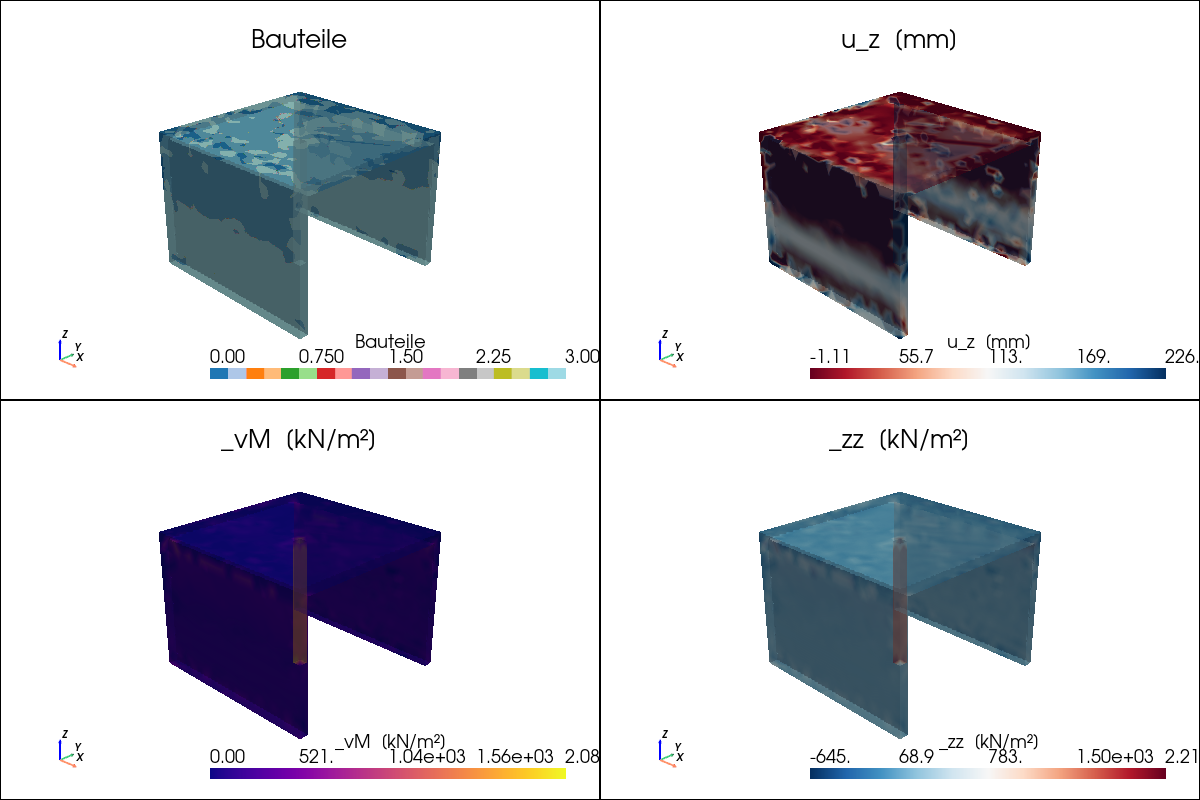

PyVista-Plot erstellt.


In [37]:
pv.set_jupyter_backend('static')

# UnstructuredGrid aus meshio-Daten aufbauen
cell_array = onp.hstack([
    onp.full((len(cells_m), 1), 4, dtype=onp.int64),
    cells_m.astype(onp.int64)
]).flatten()
cell_types = onp.full(len(cells_m), pv.CellType.TETRA)

grid = pv.UnstructuredGrid(cell_array, cell_types, points_m)

# Skalare Felder anhängen
grid.point_data['uz_mm']    = uz  * 1000
grid.point_data['u_abs_mm'] = u_abs * 1000
grid.point_data['sigma_vm'] = s_vm
grid.point_data['sigma_zz'] = s33
grid.point_data['bauteil']  = node_labels.astype(float)

# Warpfaktor: basiert auf uz (Absenkung), nicht u_abs
max_uz = max(abs(uz.min()), abs(uz.max()))
char_len = float(points_m[:,2].max() - points_m[:,2].min())  # Bauhöhe
warp_scale = min(0.05 * char_len / max(max_uz, 1e-12), 500.0)
warp_scale = max(round(warp_scale, 0), 1.0)
print(f'Warpfaktor: ×{warp_scale:.0f}')

# 4 Subplots: Bauteil | u_z | σ_vm | σ_zz
plotter = pv.Plotter(shape=(2, 2), window_size=(1200, 800))
plotter.set_background('white')

cam_pos = [(12, -8, 8), (2, 2, 1.5), (0, 0, 1)]

configs = [
    (0, 0, 'bauteil',  'Bauteile',       'tab20'),
    (0, 1, 'uz_mm',    'u_z  [mm]',      'RdBu'),
    (1, 0, 'sigma_vm', 'σ_vM  [kN/m²]',  'plasma'),
    (1, 1, 'sigma_zz', 'σ_zz  [kN/m²]',  'RdBu_r'),
]

for row, col, field, title, cmap in configs:
    plotter.subplot(row, col)
    plotter.add_mesh(grid, scalars=field, cmap=cmap, show_edges=False,
                     opacity=0.95, scalar_bar_args={'title': title})
    plotter.add_title(title, font_size=10)
    plotter.camera_position = cam_pos
    plotter.add_axes()

plotter.show(title=f'IFC → GMSH Tet4 → JaxFEM  |  {len(cells_m)} Elemente  |  h={MESH_SIZE} m')
print('PyVista-Plot erstellt.')


## 9 — Verformte Geometrie (Warp)

Deformierte Struktur mit überhöhter Darstellung der Verschiebungen.

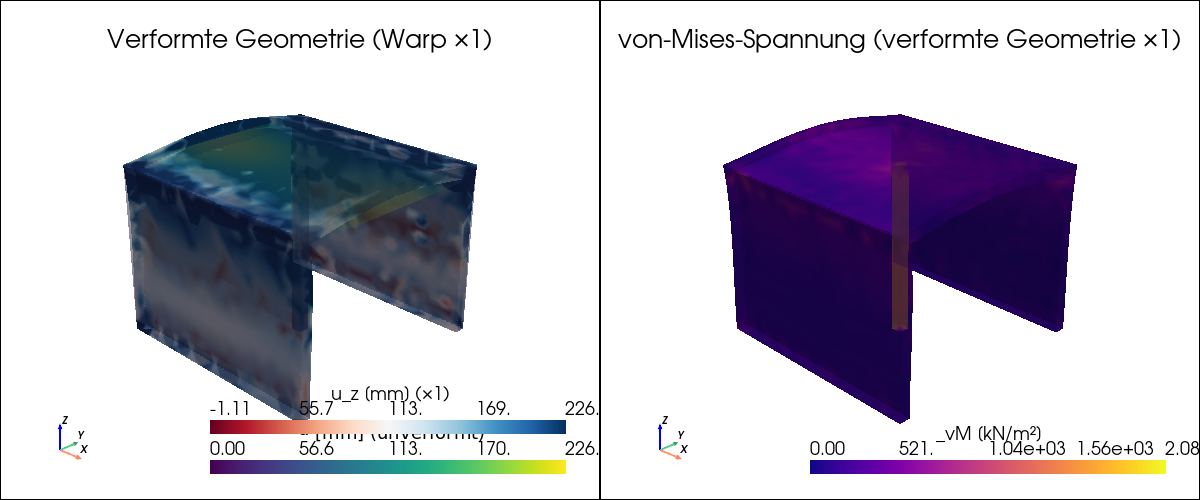

Warp-Plot gespeichert: ../data/vtk/ifc_fem_3d_warp.png


In [38]:
# Verschiebungsvektor als 3D-Array
disp_vec = onp.column_stack([ux, uy, uz])
grid.point_data['displacement'] = disp_vec

warped = grid.warp_by_vector('displacement', factor=warp_scale)
warped.point_data['sigma_vm'] = s_vm
warped.point_data['uz_mm']    = uz * 1000

plotter2 = pv.Plotter(shape=(1, 2), window_size=(1200, 500))
plotter2.set_background('white')

plotter2.subplot(0, 0)
plotter2.add_mesh(grid,   scalars='u_abs_mm', cmap='viridis',
                  opacity=0.3, show_edges=False,
                  scalar_bar_args={'title': '|u| [mm] (unverformt)'})
plotter2.add_mesh(warped, scalars='uz_mm', cmap='RdBu',
                  opacity=0.9, show_edges=False,
                  scalar_bar_args={'title': f'u_z [mm] (×{warp_scale:.0f})'})
plotter2.add_title(f'Verformte Geometrie (Warp ×{warp_scale:.0f})', font_size=10)
plotter2.camera_position = cam_pos
plotter2.add_axes()

plotter2.subplot(0, 1)
plotter2.add_mesh(warped, scalars='sigma_vm', cmap='plasma',
                  opacity=0.95, show_edges=False,
                  scalar_bar_args={'title': 'σ_vM [kN/m²]'})
plotter2.add_title(f'von-Mises-Spannung (verformte Geometrie ×{warp_scale:.0f})', font_size=10)
plotter2.camera_position = cam_pos
plotter2.add_axes()

plotter2.show()

# PNG-Export
plotter2.screenshot(str(DATA_DIR / 'vtk' / 'ifc_fem_3d_warp.png'), return_img=False)
print('Warp-Plot gespeichert:', DATA_DIR / 'vtk' / 'ifc_fem_3d_warp.png')

## 10 — Matplotlib-Schnittbilder

XZ-Schnitt (bei y ≈ Mitte) und YZ-Schnitt für σ_vM und u_z.

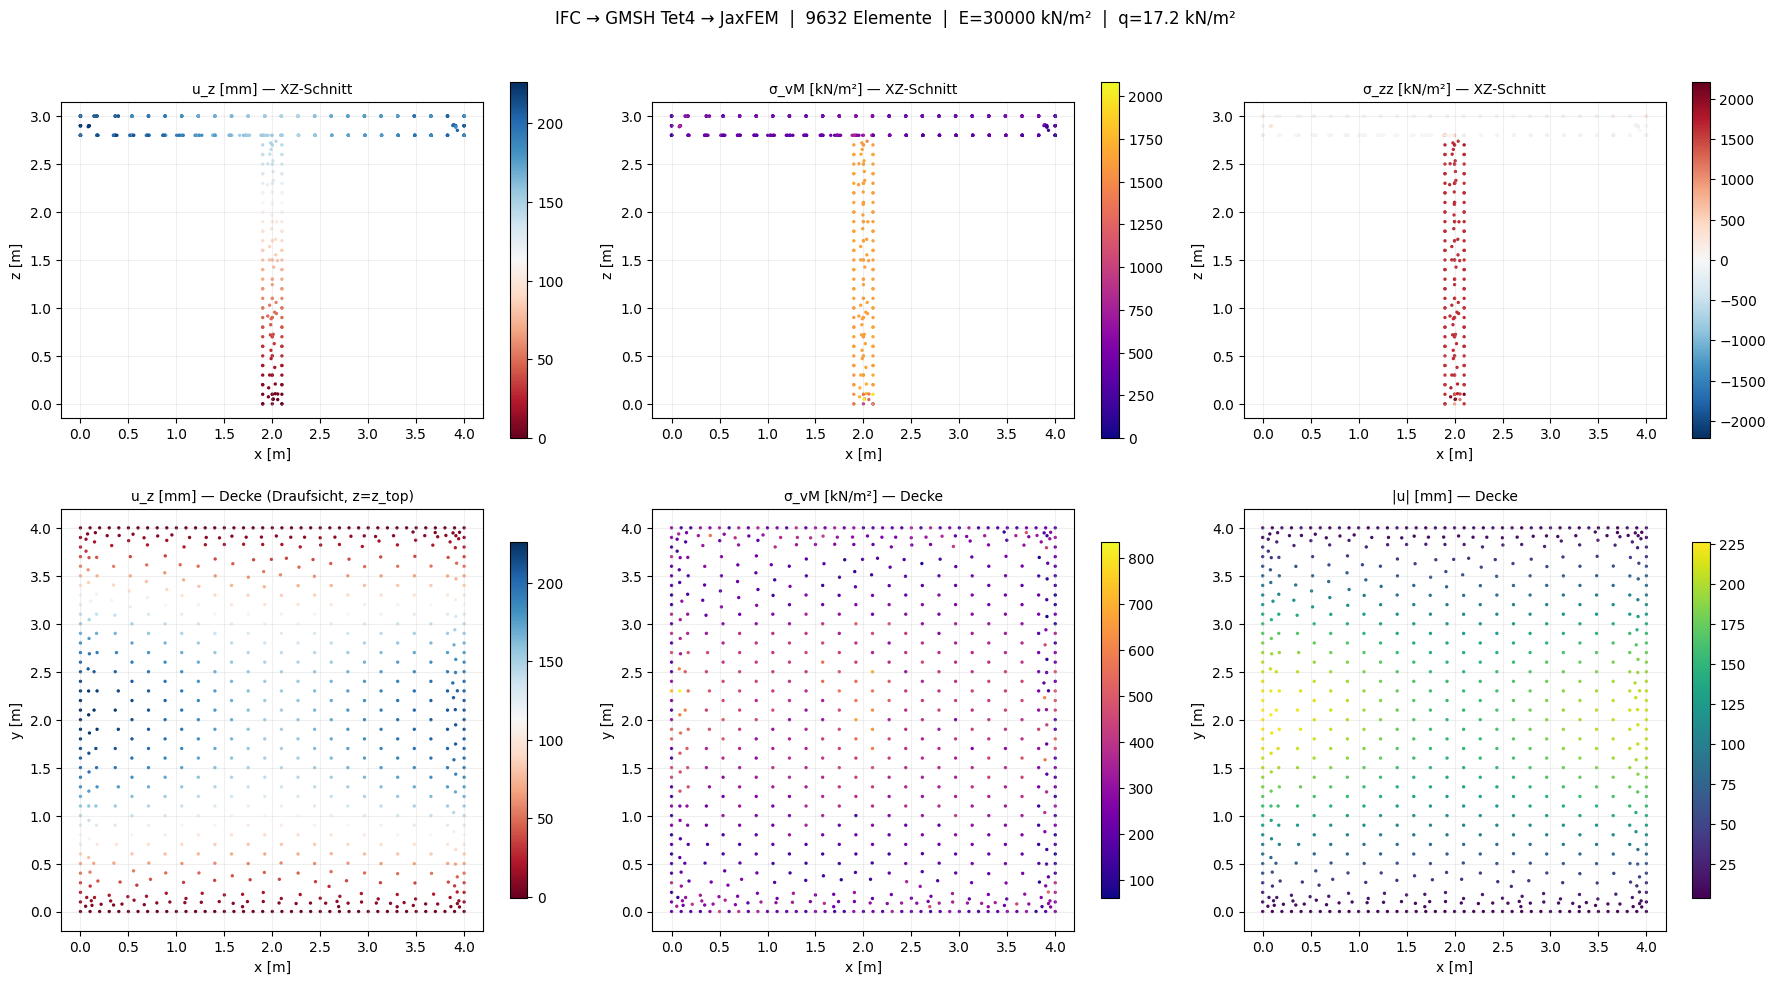

Schnitt-Plots gespeichert.


In [39]:
def schnitt_plot(ax, pts, vals, x_col, z_col, x_label, cmap, title, vmin=None, vmax=None):
    if vmin is None: vmin = vals.min()
    if vmax is None: vmax = vals.max()
    sc = ax.scatter(pts[:, x_col], pts[:, z_col], c=vals,
                    cmap=cmap, s=2, rasterized=True, vmin=vmin, vmax=vmax)
    plt.colorbar(sc, ax=ax, shrink=0.8)
    ax.set_xlabel(x_label)
    ax.set_ylabel('z [m]')
    ax.set_title(title, fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)


# XZ-Schnitt bei y ≈ Ly/2
y_mid = (points_m[:,1].min() + points_m[:,1].max()) / 2
y_tol = (points_m[:,1].max() - points_m[:,1].min()) / 6
mask_xz = onp.abs(points_m[:,1] - y_mid) < y_tol

# XY-Schnitt bei z ≈ Zmax (Decke)
z_top_s = points_m[:,2].max()
mask_xy = onp.abs(points_m[:,2] - z_top_s) < tol_bc * 3

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Zeile 1: XZ-Schnitt
p_xz = points_m[mask_xz]
schnitt_plot(axes[0,0], p_xz, uz[mask_xz]*1000, 0, 2, 'x [m]', 'RdBu', 'u_z [mm] — XZ-Schnitt')
schnitt_plot(axes[0,1], p_xz, s_vm[mask_xz],    0, 2, 'x [m]', 'plasma', 'σ_vM [kN/m²] — XZ-Schnitt')
schnitt_plot(axes[0,2], p_xz, s33[mask_xz],     0, 2, 'x [m]', 'RdBu_r', 'σ_zz [kN/m²] — XZ-Schnitt',
             vmin=-abs(s33).max(), vmax=abs(s33).max())

# Zeile 2: Draufsicht Decke (XY bei z_top)
p_xy = points_m[mask_xy]
if len(p_xy) > 0:
    schnitt_plot(axes[1,0], p_xy, uz[mask_xy]*1000, 0, 1, 'x [m]', 'RdBu', 'u_z [mm] — Decke (Draufsicht, z=z_top)')
    axes[1,0].set_ylabel('y [m]')
    schnitt_plot(axes[1,1], p_xy, s_vm[mask_xy],   0, 1, 'x [m]', 'plasma', 'σ_vM [kN/m²] — Decke')
    axes[1,1].set_ylabel('y [m]')
    schnitt_plot(axes[1,2], p_xy, u_abs[mask_xy]*1000, 0, 1, 'x [m]', 'viridis', '|u| [mm] — Decke')
    axes[1,2].set_ylabel('y [m]')
else:
    for ax in axes[1]: ax.set_visible(False)

plt.suptitle(f'IFC → GMSH Tet4 → JaxFEM  |  {len(cells_m)} Elemente  '
             f'|  E={E_eff:.0f} kN/m²  |  q={q:.1f} kN/m²', fontsize=12)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'vtk' / 'ifc_fem_3d_schnitte.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Schnitt-Plots gespeichert.')

## 11 — Bauteilweise Ergebnisse

In [40]:
print('=' * 65)
print(f'  {"Bauteil":15s}  {"uz_min [mm]":>12s}  {"u_max [mm]":>10s}  {"σ_vM_max":>10s}')
print('  ' + '-' * 52)

results_per_bauteil = []
for i, info in enumerate(elements_ifc):
    mask_b = (node_labels == i)
    if mask_b.sum() == 0:
        continue
    uz_min  = float(uz[mask_b].min() * 1000)
    u_max   = float(u_abs[mask_b].max() * 1000)
    svm_max = float(s_vm[mask_b].max())
    print(f'  {info["name"]:15s}  {uz_min:>12.3f}  {u_max:>10.3f}  {svm_max:>10.1f}')
    results_per_bauteil.append({
        'name': info['name'], 'type': info['type'], 'guid': info['guid'],
        'E_kNm2': info['E'], 'nu': info['nu'],
        'uz_min_mm': round(uz_min, 3),
        'u_max_mm': round(u_max, 3),
        'sigma_vm_max': round(svm_max, 1),
    })

print('  ' + '-' * 52)
print(f'  {"GESAMT":15s}  {uz.min()*1000:>12.3f}  {u_abs.max()*1000:>10.3f}  {s_vm.max():>10.1f}')
print('=' * 65)

# JSON-Export für CesiumJS / geobim.app
results = {
    'meta': {
        'ele_type': ele_type, 'mesh_size': MESH_SIZE,
        'n_nodes': int(len(points_m)), 'n_elements': int(len(cells_m)),
        'E_eff_kNm2': float(E_eff), 'nu_eff': float(nu_eff),
        'q_kNm2': float(q), 'units': 'kN + m',
    },
    'global': {
        'uz_max_mm':    round(float(uz.min() * 1000), 3),
        'u_abs_max_mm': round(float(u_abs.max() * 1000), 3),
        'sigma_vm_max': round(float(s_vm.max()), 1),
    },
    'per_bauteil': results_per_bauteil,
}

json_path = DATA_DIR / 'ifc_fem_3d_results.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print(f'\nJSON gespeichert: {json_path}')

  Bauteil           uz_min [mm]  u_max [mm]    σ_vM_max
  ----------------------------------------------------
  Wand_A                 -1.109      49.760       931.3
  Wand_B                 -1.043      44.406      1075.8
  Stütze_M                0.000     152.289      2083.9
  Decke_D1               -0.526     226.369       841.5
  ----------------------------------------------------
  GESAMT                 -1.109     226.369      2083.9

JSON gespeichert: ../data/ifc_fem_3d_results.json


## 12 — Zusammenfassung & Nächste Schritte

| Schritt | Status |
|---------|--------|
| GMSH Tet4-Volumennetz (Bauteil-Kontakte) | ✅ |
| JaxFEM-Solver 3D-Elastizität | ✅ |
| IFC-Property-Mapping: Material → E-Modul | ✅ |
| Ergebnisvisualisierung (PyVista + Matplotlib) | ✅ |
| VTK-Export (ParaView-kompatibel) | ✅ |
| JSON-Export (CesiumJS / geobim.app) | ✅ |

### Offene Erweiterungen

- **Heterogenes Materialfeld**: Bauteil-weise verschiedene E-Moduln (erfordert Umstrukturierung des JaxFEM-Problems)
- **Randbedingungen aus IFC**: `IfcRelConnectsStructuralMember` auslesen
- **Eigenlastvektor**: Volumenlast f_z = -γ als body_force einbinden
- **Echte IFC-Datei**: `USE_DEMO_MODEL = False`, `IFC_PATH` setzen
- **Nichtlineares Verhalten**: Plastizität, Rissbildung (Phase-Field)

In [41]:
print('=' * 55)
print('  IFC → GMSH Tet4 → JaxFEM — Zusammenfassung')
print('=' * 55)
print(f'  Elementgröße   : h = {MESH_SIZE} m')
print(f'  Tet4-Elemente  : {len(cells_m)}')
print(f'  Knoten / DOF   : {len(points_m)} / {len(points_m)*3}')
print(f'  E_eff / ν_eff  : {E_eff:.0f} kN/m²  /  {nu_eff:.2f}')
print(f'  Deckenlast     : {q:.1f} kN/m²  (EG+Nutzlast)')
print('-' * 55)
print(f'  u_z_max        : {uz.min()*1000:.3f} mm')
print(f'  |u|_max        : {u_abs.max()*1000:.3f} mm')
print(f'  σ_vM_max       : {s_vm.max():.1f} kN/m²')
print(f'  σ_zz_min       : {s33.min():.1f} kN/m²  (Druckspannung)')
print('=' * 55)

  IFC → GMSH Tet4 → JaxFEM — Zusammenfassung
  Elementgröße   : h = 0.2 m
  Tet4-Elemente  : 9632
  Knoten / DOF   : 3058 / 9174
  E_eff / ν_eff  : 30000 kN/m²  /  0.20
  Deckenlast     : 17.2 kN/m²  (EG+Nutzlast)
-------------------------------------------------------
  u_z_max        : -1.109 mm
  |u|_max        : 226.369 mm
  σ_vM_max       : 2083.9 kN/m²
  σ_zz_min       : -645.0 kN/m²  (Druckspannung)
